# Laboratorio 05: CNN vs Multi-Head Attention — Food-101

**Objetivo:** Comparar el rendimiento de una **CNN** (ResNet-18 con transfer learning) contra un modelo basado en **Multi-Head Attention** (Vision Transformer) entrenado desde cero, para clasificar 10 categorías del dataset Food-101.

**Contenido:**
1. Carga y exploración del dataset
2. Data augmentation y DataLoaders
3. Funciones auxiliares de entrenamiento/evaluación
4. Modelo CNN (ResNet-18, transfer learning)
5. Modelo Mini ViT (Multi-Head Attention desde cero)
6. Comparación final de resultados

In [10]:
%matplotlib inline

import os, time, copy, random
import numpy as np
from PIL import Image
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm.auto import tqdm

# ─── Reproducibilidad ───
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─── GPU ───
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ─── Hiperparámetros ───
DATA_ROOT = 'food-101'
IMG_SIZE = 128
BATCH_SIZE = 64
NUM_WORKERS = 0   # 0 para compatibilidad con Windows/Jupyter

SELECTED_CLASSES = [
    'pizza', 'sushi', 'hamburger', 'ice_cream', 'ramen',
    'tacos', 'steak', 'french_fries', 'spaghetti_bolognese', 'cheesecake'
]
NUM_CLASSES = len(SELECTED_CLASSES)

# CNN hiperparámetros
CNN_EPOCHS = 15
CNN_LR_BACKBONE = 1e-4
CNN_LR_HEAD = 1e-3

# ViT hiperparámetros
VIT_EPOCHS = 40
VIT_LR = 3e-4
VIT_PATCH_SIZE = 16
VIT_EMBED_DIM = 256
VIT_NUM_HEADS = 4
VIT_NUM_LAYERS = 4
VIT_MLP_DIM = 512
VIT_DROPOUT = 0.1

PATIENCE = 8

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
VRAM: 8.5 GB


## 1. Carga y Exploración del Dataset

Se seleccionan **10 clases** visualmente diversas de Food-101 (101 clases originales, cada una con 1,000 imágenes).

- Split oficial: **750 train / 250 test** por clase
- Se crea un **split de validación** (80/20 estratificado) del conjunto de entrenamiento
- Se calculan **pesos de clase** para la función de pérdida (buena práctica ante posible desbalanceo)

Train: 6000 | Val: 1500 | Test: 2500

Distribución por clase (train):
                      pizza: 600
                      sushi: 600
                  hamburger: 600
                  ice_cream: 600
                      ramen: 600
                      tacos: 600
                      steak: 600
               french_fries: 600
        spaghetti_bolognese: 600
                 cheesecake: 600

Pesos de clase: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


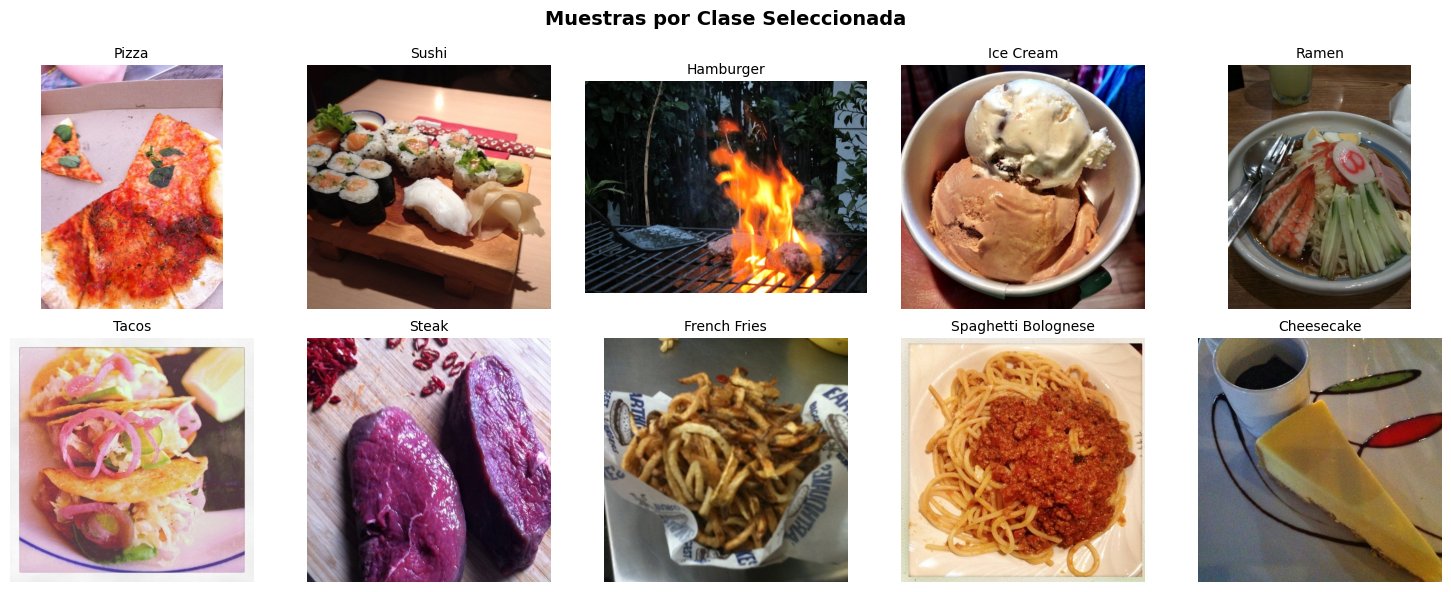

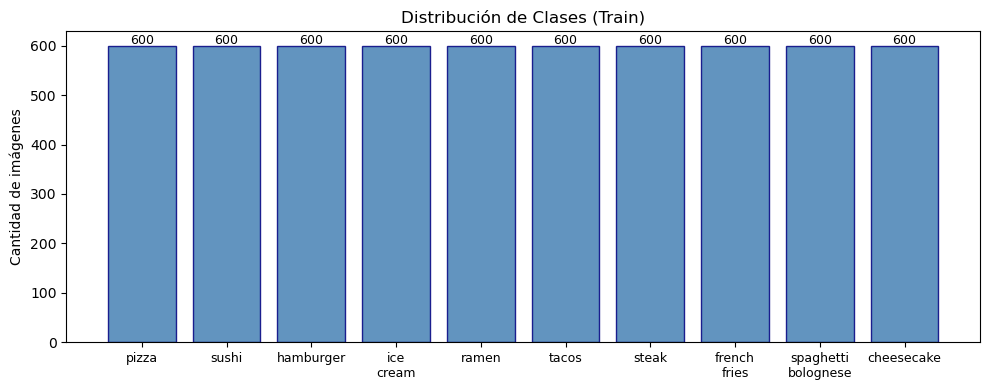

In [2]:
# ─── Leer splits oficiales ───
with open(os.path.join(DATA_ROOT, 'meta', 'train.txt')) as f:
    all_train = [l.strip() for l in f if l.strip()]
with open(os.path.join(DATA_ROOT, 'meta', 'test.txt')) as f:
    all_test = [l.strip() for l in f if l.strip()]

# ─── Filtrar clases seleccionadas ───
class_set = set(SELECTED_CLASSES)
train_entries = [e for e in all_train if e.split('/')[0] in class_set]
test_entries  = [e for e in all_test  if e.split('/')[0] in class_set]

# ─── Split train → train + val (estratificado) ───
train_labels_str = [e.split('/')[0] for e in train_entries]
train_files, val_files = train_test_split(
    train_entries, test_size=0.2, random_state=SEED, stratify=train_labels_str
)
print(f'Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_entries)}')

# ─── Distribución de clases ───
train_counts = Counter(e.split('/')[0] for e in train_files)
print('\nDistribución por clase (train):')
for cls in SELECTED_CLASSES:
    print(f'  {cls:>25s}: {train_counts[cls]}')

# ─── Pesos de clase (inversamente proporcional) ───
class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}
total_samples = len(train_files)
class_weights = torch.zeros(NUM_CLASSES)
for cls, count in train_counts.items():
    class_weights[class_to_idx[cls]] = total_samples / (NUM_CLASSES * count)
class_weights = class_weights.to(device)
print(f'\nPesos de clase: {class_weights.cpu().numpy().round(4)}')

# ─── Visualizar muestras ───
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Muestras por Clase Seleccionada', fontsize=14, fontweight='bold')
for i, cls in enumerate(SELECTED_CLASSES):
    ax = axes[i // 5, i % 5]
    sample = [e for e in train_files if e.startswith(cls + '/')][0]
    img = Image.open(os.path.join(DATA_ROOT, 'images', sample + '.jpg'))
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' ').title(), fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

# ─── Gráfico de barras de distribución ───
fig, ax = plt.subplots(figsize=(10, 4))
counts_list = [train_counts[c] for c in SELECTED_CLASSES]
bars = ax.bar(range(NUM_CLASSES), counts_list, color='steelblue',
              edgecolor='navy', alpha=0.85)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([c.replace('_', '\n') for c in SELECTED_CLASSES], fontsize=9)
ax.set_ylabel('Cantidad de imágenes')
ax.set_title('Distribución de Clases (Train)')
for bar, c in zip(bars, counts_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(c), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Data Augmentation y DataLoaders

**Train:** RandomResizedCrop, RandomHorizontalFlip, ColorJitter, RandomRotation + normalización ImageNet

**Val/Test:** Resize + CenterCrop determinístico + normalización ImageNet

In [ ]:
class Food101Dataset(Dataset):  
    '''Dataset personalizado para Food-101 (subconjunto).'''
    def __init__(self, file_list, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = [(e, class_to_idx[e.split('/')[0]]) for e in file_list]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        entry, label = self.samples[idx]
        img_path = os.path.join(self.root_dir, 'images', entry + '.jpg')
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


# ─── Transformaciones ───
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE + 16),     # 144
    transforms.CenterCrop(IMG_SIZE),       # 128
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ─── Datasets ───
train_dataset = Food101Dataset(train_files, DATA_ROOT, class_to_idx, train_transform)
val_dataset   = Food101Dataset(val_files,   DATA_ROOT, class_to_idx, test_transform)
test_dataset  = Food101Dataset(test_entries, DATA_ROOT, class_to_idx, test_transform)

# ─── DataLoaders ───
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train: {len(train_dataset)} imgs ({len(train_loader)} batches)')
print(f'Val:   {len(val_dataset)} imgs ({len(val_loader)} batches)')
print(f'Test:  {len(test_dataset)} imgs ({len(test_loader)} batches)')

# Verificar un batch
imgs, labels = next(iter(train_loader))
print(f'\nBatch shape: {imgs.shape} | Labels sample: {labels[:8].tolist()}')

Train: 6000 imgs (94 batches)
Val:   1500 imgs (24 batches)
Test:  2500 imgs (40 batches)

Batch shape: torch.Size([64, 3, 128, 128]) | Labels sample: [0, 4, 5, 9, 1, 6, 7, 6]


## 3. Funciones Auxiliares

Funciones reutilizables para entrenamiento, evaluación y visualización de ambos modelos.

In [4]:
def count_parameters(model):
    '''Cuenta parámetros totales y entrenables.'''
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler, num_epochs, device, patience=5, name='Modelo'):
    '''Entrena un modelo con early stopping y ReduceLROnPlateau.'''
    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_state = None
    wait = 0
    t0 = time.time()

    for epoch in range(num_epochs):
        # ── Entrenamiento ──
        model.train()
        rloss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f'{name} [{epoch+1}/{num_epochs}]', leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            rloss += loss.item() * images.size(0)
            _, pred = out.max(1)
            total += labels.size(0)
            correct += pred.eq(labels).sum().item()
            pbar.set_postfix(loss=f'{rloss/total:.3f}', acc=f'{correct/total:.3f}')
        train_loss = rloss / total
        train_acc = correct / total

        # ── Validación ──
        model.eval()
        vloss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out = model(images)
                loss = criterion(out, labels)
                vloss += loss.item() * images.size(0)
                _, pred = out.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()
        val_loss = vloss / total
        val_acc = correct / total
        scheduler.step(val_loss)

        hist['train_loss'].append(train_loss)
        hist['train_acc'].append(train_acc)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)

        lr = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch+1:2d} | Train: loss={train_loss:.4f} acc={train_acc:.4f} | '
              f'Val: loss={val_loss:.4f} acc={val_acc:.4f} | lr={lr:.1e}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stopping (epoch {epoch+1})')
                break

    elapsed = time.time() - t0
    print(f'\n  {name} listo: {elapsed/60:.1f} min | Mejor val acc: {best_acc:.4f}')
    model.load_state_dict(best_state)
    return model, hist, elapsed


def evaluate_model(model, loader, class_names, device):
    '''Evalúa modelo en un DataLoader y retorna métricas.'''
    model.eval()
    all_pred, all_true, all_prob = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluando', leave=False):
            images = images.to(device)
            out = model(images)
            prob = F.softmax(out, dim=1)
            _, pred = out.max(1)
            all_pred.extend(pred.cpu().numpy())
            all_true.extend(labels.numpy())
            all_prob.extend(prob.cpu().numpy())

    y_true = np.array(all_true)
    y_pred = np.array(all_pred)
    y_prob = np.array(all_prob)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    top3 = np.mean([y_true[i] in np.argsort(y_prob[i])[-3:]
                    for i in range(len(y_true))])
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True)

    return dict(accuracy=acc, f1_macro=f1, top3_accuracy=top3,
                cm=cm, report=report, report_dict=report_dict,
                y_true=y_true, y_pred=y_pred, y_prob=y_prob)


def plot_curves(history, title):
    '''Grafica curvas de loss y accuracy.'''
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    ep = range(1, len(history['train_loss']) + 1)
    ax1.plot(ep, history['train_loss'], 'b-o', ms=4, label='Train')
    ax1.plot(ep, history['val_loss'],   'r-o', ms=4, label='Val')
    ax1.set(xlabel='Época', ylabel='Loss', title=f'{title} — Loss')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, history['train_acc'], 'b-o', ms=4, label='Train')
    ax2.plot(ep, history['val_acc'],   'r-o', ms=4, label='Val')
    ax2.set(xlabel='Época', ylabel='Accuracy', title=f'{title} — Accuracy')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_cm(cm, class_names, title, cmap='Blues'):
    '''Matriz de confusión como heatmap.'''
    labels = [c.replace('_', ' ').title() for c in class_names]
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set(xlabel='Predicción', ylabel='Real', title=title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

## 4. Modelo CNN — ResNet-18 con Transfer Learning

Se utiliza **ResNet-18** pre-entrenado en ImageNet. Se descongelan las últimas dos capas residuales (`layer3`, `layer4`) y se reemplaza el clasificador final.

**Ventaja:** Aprovecha representaciones aprendidas en ImageNet (1.2M imágenes), adaptándolas al dominio de comida con pocas épocas de fine-tuning.

In [5]:
# ─── Crear CNN ───
def create_cnn(num_classes):
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    # Congelar todo
    for p in model.parameters():
        p.requires_grad = False
    # Descongelar últimas 2 capas residuales
    for p in model.layer3.parameters():
        p.requires_grad = True
    for p in model.layer4.parameters():
        p.requires_grad = True
    # Nuevo clasificador
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

cnn = create_cnn(NUM_CLASSES).to(device)
tr, tot = count_parameters(cnn)
print(f'CNN (ResNet-18): {tot:,} total | {tr:,} entrenables ({100*tr/tot:.1f}%)')

# ─── Configurar entrenamiento ───
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
cnn_optimizer = torch.optim.AdamW([
    {'params': list(cnn.layer3.parameters()) + list(cnn.layer4.parameters()),
     'lr': CNN_LR_BACKBONE},
    {'params': cnn.fc.parameters(), 'lr': CNN_LR_HEAD},
], weight_decay=1e-4)
cnn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, factor=0.5, patience=2)

# ─── Entrenar ───
print('\nIniciando entrenamiento CNN...\n')
cnn, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, cnn_criterion, cnn_optimizer,
    cnn_scheduler, CNN_EPOCHS, device, PATIENCE, 'CNN')

CNN (ResNet-18): 11,181,642 total | 10,498,570 entrenables (93.9%)

Iniciando entrenamiento CNN...



CNN [1/15]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep  1 | Train: loss=1.1341 acc=0.6303 | Val: loss=0.7419 acc=0.7667 | lr=1.0e-04


CNN [2/15]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep  2 | Train: loss=0.6147 acc=0.8038 | Val: loss=0.6675 acc=0.7887 | lr=1.0e-04


...

  Ep 13 | Train: loss=0.0595 acc=0.9833 | Val: loss=0.6761 acc=0.8273 | lr=1.3e-05


CNN [14/15]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep 14 | Train: loss=0.0614 acc=0.9813 | Val: loss=0.6710 acc=0.8253 | lr=1.3e-05


CNN [15/15]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep 15 | Train: loss=0.0535 acc=0.9843 | Val: loss=0.6763 acc=0.8227 | lr=6.3e-06

  CNN listo: 7.3 min | Mejor val acc: 0.8273


RESULTADOS CNN (ResNet-18) — TEST SET


Evaluando:   0%|          | 0/40 [00:00<?, ?it/s]


  Accuracy:   0.8868
  F1 macro:   0.8865
  Top-3 Acc:  0.9736

                     precision    recall  f1-score   support

              pizza       0.91      0.94      0.93       250
              sushi       0.86      0.87      0.87       250
          hamburger       0.85      0.85      0.85       250
          ice_cream       0.89      0.84      0.86       250
              ramen       0.90      0.94      0.92       250
              tacos       0.85      0.83      0.84       250
              steak       0.85      0.88      0.86       250
       french_fries       0.94      0.95      0.94       250
spaghetti_bolognese       0.91      0.92      0.92       250
         cheesecake       0.91      0.84      0.88       250

           accuracy                           0.89      2500
          macro avg       0.89      0.89      0.89      2500
       weighted avg       0.89      0.89      0.89      2500



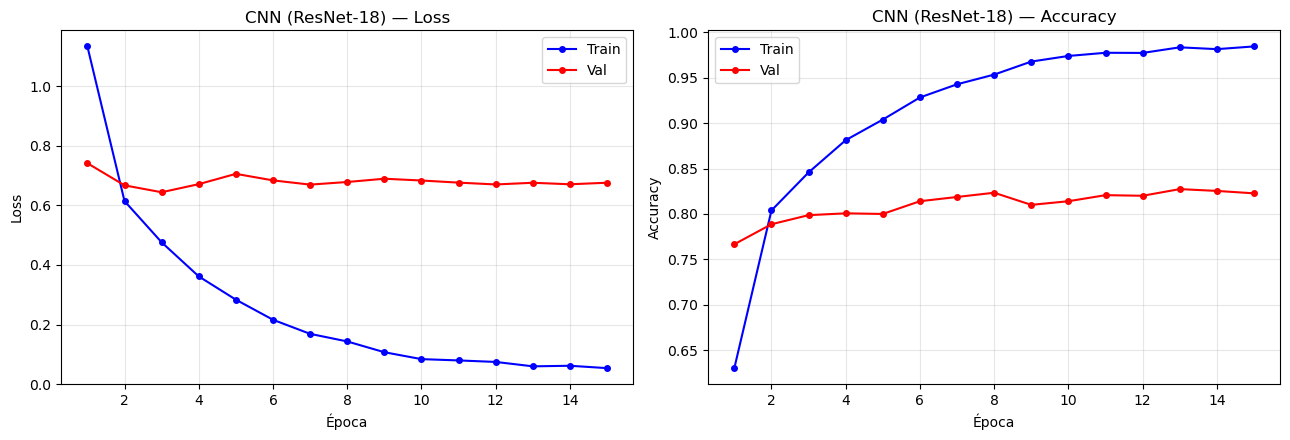

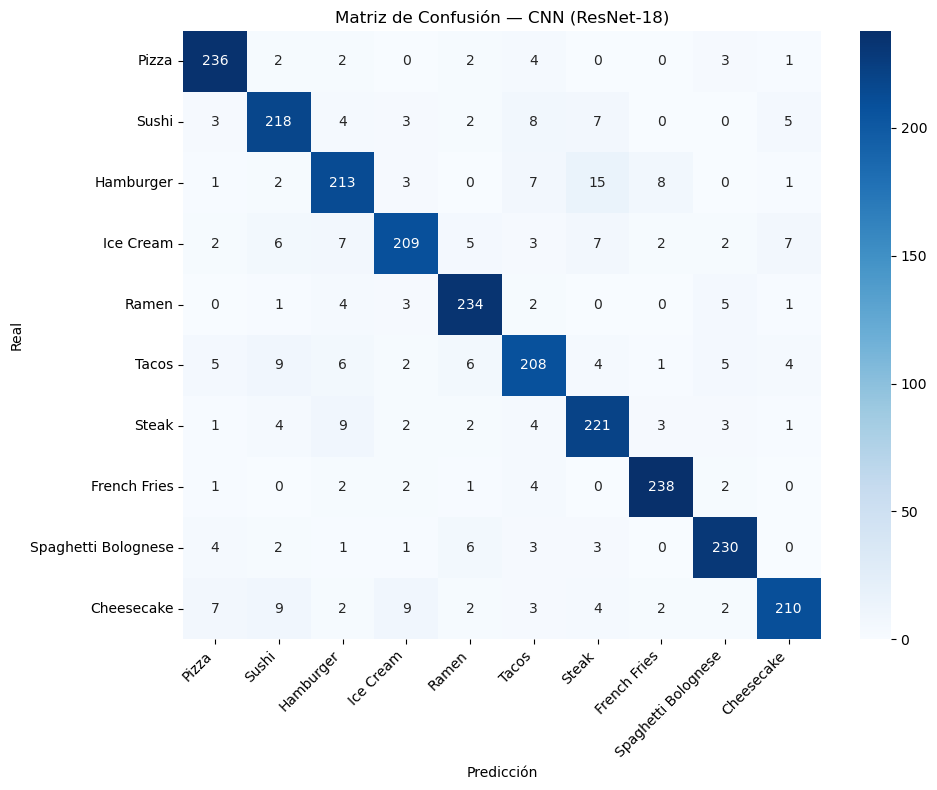

In [6]:
print('=' * 60)
print('RESULTADOS CNN (ResNet-18) — TEST SET')
print('=' * 60)
cnn_res = evaluate_model(cnn, test_loader, SELECTED_CLASSES, device)

print(f'\n  Accuracy:   {cnn_res["accuracy"]:.4f}')
print(f'  F1 macro:   {cnn_res["f1_macro"]:.4f}')
print(f'  Top-3 Acc:  {cnn_res["top3_accuracy"]:.4f}')
print(f'\n{cnn_res["report"]}')

plot_curves(cnn_hist, 'CNN (ResNet-18)')
plot_cm(cnn_res['cm'], SELECTED_CLASSES,
        'Matriz de Confusión — CNN (ResNet-18)')

## 5. Modelo Mini ViT — Multi-Head Attention

Vision Transformer (ViT) minimalista construido **desde cero**:

| Componente | Detalle |
|---|---|
| **Patch Embedding** | Conv2d divide la imagen en parches de 16×16 → 64 patches |
| **Positional Encoding** | Embeddings posicionales aprendibles |
| **CLS Token** | Token especial para clasificación |
| **Transformer Encoder** | 4 capas × 4 heads de Multi-Head Attention |
| **Clasificador** | MLP sobre el CLS token |

> **Nota:** A diferencia del CNN, este modelo se entrena **desde cero** sin pre-entrenamiento. Los ViT típicamente requieren datasets más grandes para alcanzar su máximo potencial.

In [11]:
class PatchEmbedding(nn.Module):
    '''Convierte imagen en secuencia de patch embeddings.'''
    def __init__(self, img_size, patch_size, in_ch, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)  # (B, N, D)


class MiniViT(nn.Module):
    '''Vision Transformer minimalista con Multi-Head Attention.'''
    def __init__(self, img_size=128, patch_size=16, in_ch=3,
                 embed_dim=256, n_heads=4, n_layers=4,
                 mlp_dim=512, n_classes=10, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_ch, embed_dim)
        n_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim) * 0.02)
        self.pos_drop  = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=mlp_dim, dropout=dropout,
            activation='gelu', batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, n_classes))

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)                           # (B, N, D)
        cls = self.cls_token.expand(B, -1, -1)            # (B, 1, D)
        x = self.pos_drop(torch.cat([cls, x], dim=1)      # (B, N+1, D)
                          + self.pos_embed)
        x = self.encoder(x)                               # Transformer
        return self.head(self.norm(x[:, 0]))               # CLS → clase


# ─── Crear modelo ViT ───
vit = MiniViT(
    img_size=IMG_SIZE, patch_size=VIT_PATCH_SIZE,
    embed_dim=VIT_EMBED_DIM, n_heads=VIT_NUM_HEADS,
    n_layers=VIT_NUM_LAYERS, mlp_dim=VIT_MLP_DIM,
    n_classes=NUM_CLASSES, dropout=VIT_DROPOUT
).to(device)

tr, tot = count_parameters(vit)
print(f'Mini ViT: {tot:,} total | {tr:,} entrenables')
print(f'Secuencia: 1 CLS + {vit.patch_embed.num_patches} patches '
      f'= {vit.patch_embed.num_patches + 1} tokens')

# ─── Configurar entrenamiento ───
vit_criterion = nn.CrossEntropyLoss(weight=class_weights)
vit_optimizer = torch.optim.AdamW(
    vit.parameters(), lr=VIT_LR, weight_decay=1e-4)
vit_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vit_optimizer, factor=0.5, patience=2)

# ─── Entrenar ───
print('\nIniciando entrenamiento ViT...\n')
vit, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, vit_criterion, vit_optimizer,
    vit_scheduler, VIT_EPOCHS, device, PATIENCE, 'ViT')

Mini ViT: 2,356,874 total | 2,356,874 entrenables
Secuencia: 1 CLS + 64 patches = 65 tokens

Iniciando entrenamiento ViT...



C:\Users\josia\AppData\Local\Temp\ipykernel_27908\65379462.py:30: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


ViT [1/40]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep  1 | Train: loss=2.1982 acc=0.1860 | Val: loss=2.1179 acc=0.2220 | lr=3.0e-04


ViT [2/40]:   0%|          | 0/94 [00:00<?, ?it/s]

...

  Ep 38 | Train: loss=1.3409 acc=0.5480 | Val: loss=1.4463 acc=0.5247 | lr=3.7e-05


ViT [39/40]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep 39 | Train: loss=1.3354 acc=0.5495 | Val: loss=1.4370 acc=0.5240 | lr=3.7e-05


ViT [40/40]:   0%|          | 0/94 [00:00<?, ?it/s]

  Ep 40 | Train: loss=1.3318 acc=0.5472 | Val: loss=1.4330 acc=0.5240 | lr=3.7e-05

  ViT listo: 19.0 min | Mejor val acc: 0.5247


RESULTADOS Mini ViT — TEST SET


Evaluando:   0%|          | 0/40 [00:00<?, ?it/s]


  Accuracy:   0.5676
  F1 macro:   0.5661
  Top-3 Acc:  0.8328

                     precision    recall  f1-score   support

              pizza       0.70      0.59      0.64       250
              sushi       0.61      0.41      0.49       250
          hamburger       0.43      0.53      0.47       250
          ice_cream       0.49      0.44      0.47       250
              ramen       0.61      0.55      0.58       250
              tacos       0.47      0.48      0.47       250
              steak       0.58      0.65      0.61       250
       french_fries       0.60      0.75      0.67       250
spaghetti_bolognese       0.62      0.66      0.64       250
         cheesecake       0.63      0.61      0.62       250

           accuracy                           0.57      2500
          macro avg       0.57      0.57      0.57      2500
       weighted avg       0.57      0.57      0.57      2500



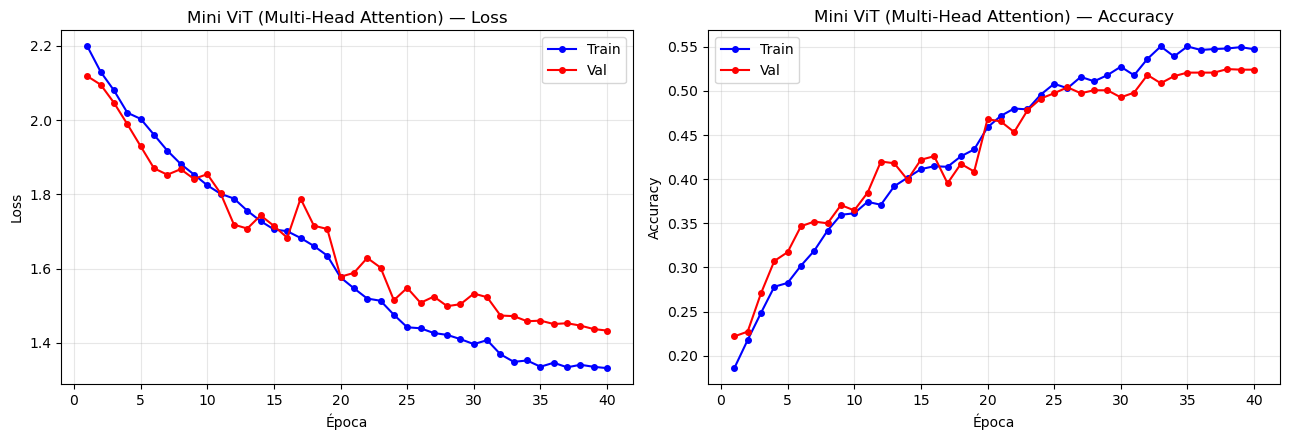

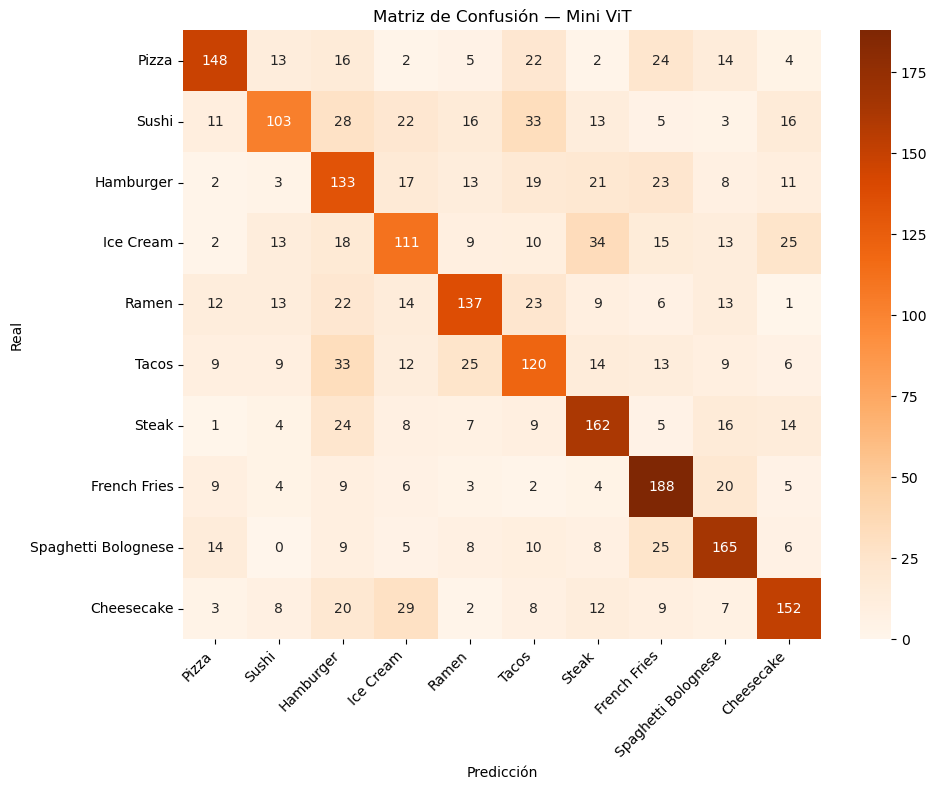

In [12]:
print('=' * 60)
print('RESULTADOS Mini ViT — TEST SET')
print('=' * 60)
vit_res = evaluate_model(vit, test_loader, SELECTED_CLASSES, device)

print(f'\n  Accuracy:   {vit_res["accuracy"]:.4f}')
print(f'  F1 macro:   {vit_res["f1_macro"]:.4f}')
print(f'  Top-3 Acc:  {vit_res["top3_accuracy"]:.4f}')
print(f'\n{vit_res["report"]}')

plot_curves(vit_hist, 'Mini ViT (Multi-Head Attention)')
plot_cm(vit_res['cm'], SELECTED_CLASSES,
        'Matriz de Confusión — Mini ViT', cmap='Oranges')

## 6. Comparación Final de Resultados

Análisis comparativo del rendimiento de ambos modelos: tabla de métricas, F1-score por clase, matrices de confusión lado a lado, y análisis de errores.


Métrica                      CNN (ResNet-18)        Mini ViT
------------------------------------------------------------
Accuracy                              0.8868          0.5676
F1 Score (macro)                      0.8865          0.5661
Top-3 Accuracy                        0.9736          0.8328
Params (total)                    11,181,642       2,356,874
Params (train)                    10,498,570       2,356,874
Tiempo (min)                             7.3            19.0
------------------------------------------------------------


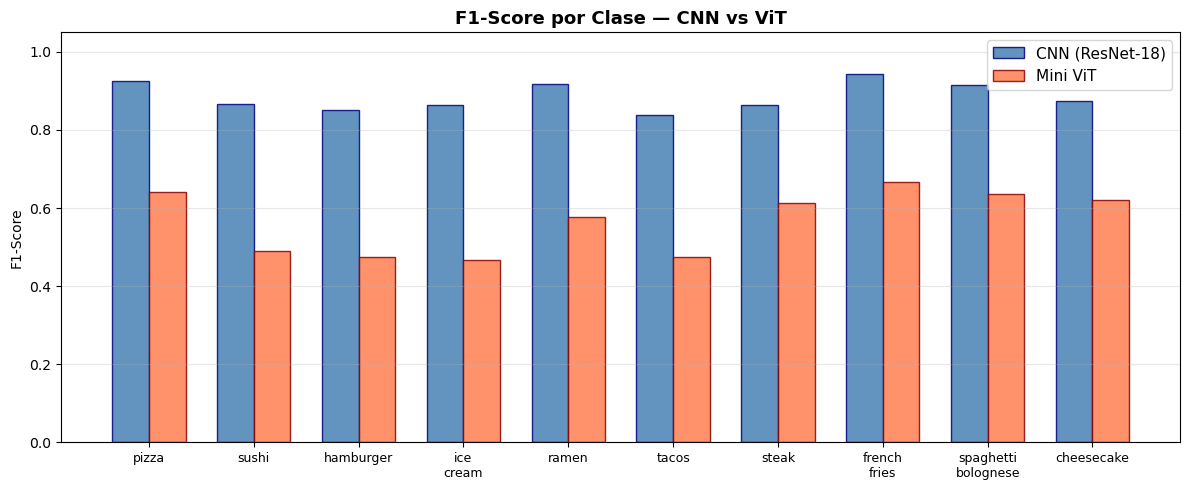

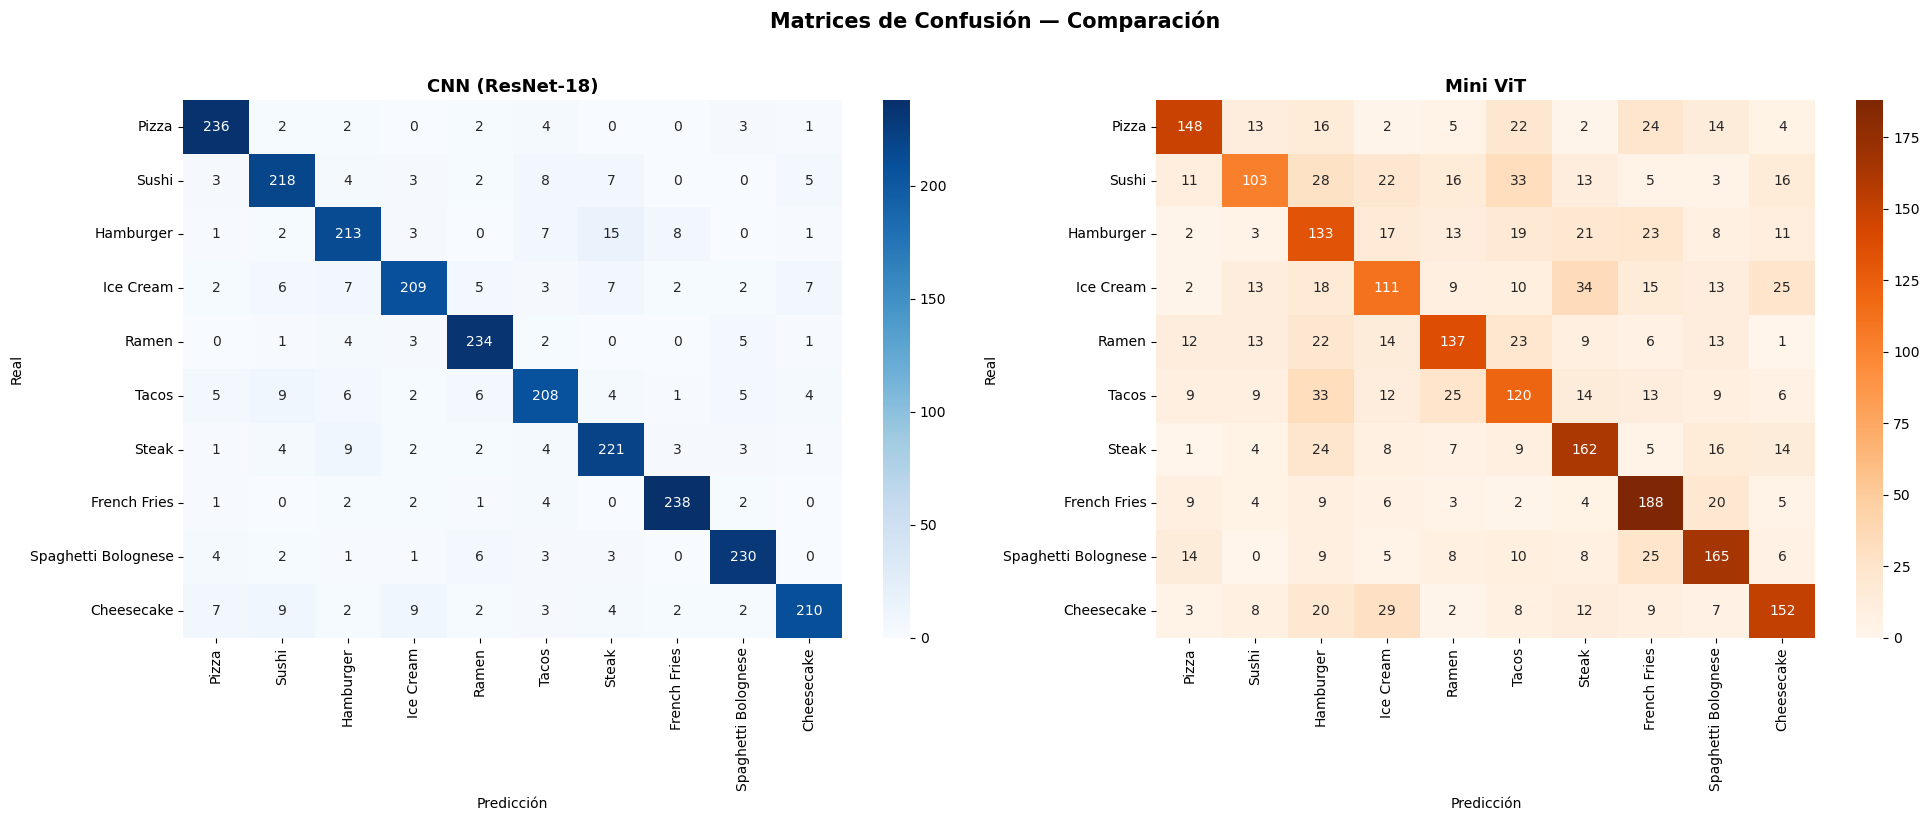

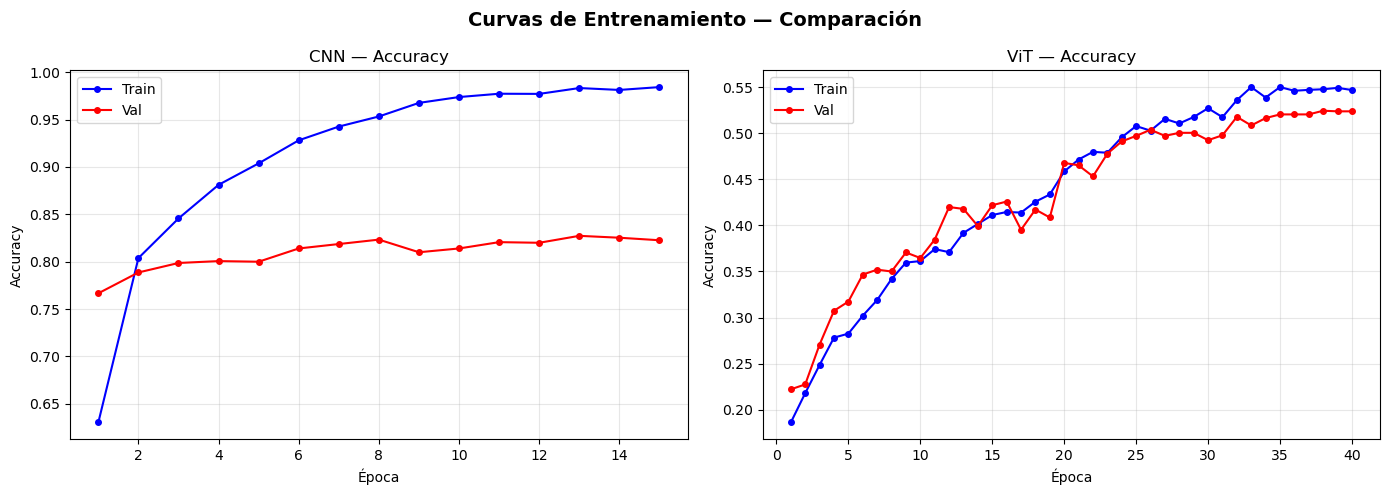


Análisis de Errores (2500 muestras de test):
  Ambos aciertan:    1328 (53.1%)
  Solo CNN acierta:   889 (35.6%)
  Solo ViT acierta:    91 (3.6%)
  Ambos fallan:       192 (7.7%)


In [13]:
# ─── Tabla resumen ───
cnn_tr, cnn_tot = count_parameters(cnn)
vit_tr, vit_tot = count_parameters(vit)

rows = [
    ('Accuracy',         f'{cnn_res["accuracy"]:.4f}',      f'{vit_res["accuracy"]:.4f}'),
    ('F1 Score (macro)', f'{cnn_res["f1_macro"]:.4f}',      f'{vit_res["f1_macro"]:.4f}'),
    ('Top-3 Accuracy',   f'{cnn_res["top3_accuracy"]:.4f}', f'{vit_res["top3_accuracy"]:.4f}'),
    ('Params (total)',   f'{cnn_tot:,}',                     f'{vit_tot:,}'),
    ('Params (train)',   f'{cnn_tr:,}',                      f'{vit_tr:,}'),
    ('Tiempo (min)',     f'{cnn_time/60:.1f}',               f'{vit_time/60:.1f}'),
]

header = f'{"Métrica":<28s} {"CNN (ResNet-18)":>15s} {"Mini ViT":>15s}'
print('\n' + header)
print('-' * len(header))
for name, v1, v2 in rows:
    print(f'{name:<28s} {v1:>15s} {v2:>15s}')
print('-' * len(header))

# ─── F1 por clase (barras comparativas) ───
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(NUM_CLASSES)
w = 0.35
cnn_f1 = [cnn_res['report_dict'][c]['f1-score'] for c in SELECTED_CLASSES]
vit_f1 = [vit_res['report_dict'][c]['f1-score'] for c in SELECTED_CLASSES]
ax.bar(x - w/2, cnn_f1, w, label='CNN (ResNet-18)',
       color='steelblue', edgecolor='navy', alpha=0.85)
ax.bar(x + w/2, vit_f1, w, label='Mini ViT',
       color='coral', edgecolor='darkred', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in SELECTED_CLASSES], fontsize=9)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score por Clase — CNN vs ViT', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# ─── Matrices de confusión lado a lado ───
labels_cm = [c.replace('_', ' ').title() for c in SELECTED_CLASSES]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cnn_res['cm'], annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax1)
ax1.set(xlabel='Predicción', ylabel='Real')
ax1.set_title('CNN (ResNet-18)', fontsize=13, fontweight='bold')

sns.heatmap(vit_res['cm'], annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_cm, yticklabels=labels_cm, ax=ax2)
ax2.set(xlabel='Predicción', ylabel='Real')
ax2.set_title('Mini ViT', fontsize=13, fontweight='bold')

plt.suptitle('Matrices de Confusión — Comparación',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# ─── Curvas de accuracy lado a lado ───
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep_c = range(1, len(cnn_hist['val_acc']) + 1)
ep_v = range(1, len(vit_hist['val_acc']) + 1)

ax1.plot(ep_c, cnn_hist['train_acc'], 'b-o', ms=4, label='Train')
ax1.plot(ep_c, cnn_hist['val_acc'],   'r-o', ms=4, label='Val')
ax1.set(title='CNN — Accuracy', xlabel='Época', ylabel='Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ep_v, vit_hist['train_acc'], 'b-o', ms=4, label='Train')
ax2.plot(ep_v, vit_hist['val_acc'],   'r-o', ms=4, label='Val')
ax2.set(title='ViT — Accuracy', xlabel='Época', ylabel='Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Curvas de Entrenamiento — Comparación',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ─── Análisis de errores ───
cnn_ok = cnn_res['y_pred'] == cnn_res['y_true']
vit_ok = vit_res['y_pred'] == vit_res['y_true']
n = len(cnn_res['y_true'])

both_ok   = np.sum(cnn_ok & vit_ok)
only_cnn  = np.sum(cnn_ok & ~vit_ok)
only_vit  = np.sum(~cnn_ok & vit_ok)
both_fail = np.sum(~cnn_ok & ~vit_ok)

print(f'\nAnálisis de Errores ({n} muestras de test):')
print(f'  Ambos aciertan:    {both_ok:4d} ({100*both_ok/n:.1f}%)')
print(f'  Solo CNN acierta:  {only_cnn:4d} ({100*only_cnn/n:.1f}%)')
print(f'  Solo ViT acierta:  {only_vit:4d} ({100*only_vit/n:.1f}%)')
print(f'  Ambos fallan:      {both_fail:4d} ({100*both_fail/n:.1f}%)')

## 7. Conclusiones

### CNN (ResNet-18 con Transfer Learning)
- Aprovecha representaciones pre-entrenadas de ImageNet → convergencia rápida y alto rendimiento
- El fine-tuning selectivo (solo capas finales) es eficiente en cómputo y previene sobreajuste
- Ideal cuando se tiene un dataset relativamente pequeño

### Mini ViT (Multi-Head Attention)
- Entrenado desde cero → necesita más datos y épocas para aprender representaciones útiles
- Multi-Head Attention captura relaciones **globales** entre parches de la imagen
- Con datasets más grandes o pre-entrenamiento (ej. ViT-Base en ImageNet-21k), los ViT pueden igualar o superar a las CNN

### Observaciones Generales
- **Transfer learning** es fundamental con datasets pequeños/medianos
- **Data augmentation** regulariza ambos modelos y reduce sobreajuste
- Los **pesos de clase** en la función de pérdida aseguran equidad entre clases (buena práctica, aunque el dataset esté balanceado)
- La **matriz de confusión** identifica pares de clases frecuentemente confundidas, guiando mejoras futuras (ej. más datos, augmentation dirigido)
- Las **curvas de entrenamiento** permiten detectar sobreajuste (gap creciente entre train y val)

---
*Laboratorio 05 — Inteligencia Artificial II*